In [35]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline 

plt.rcParams['figure.figsize'] = (12, 6)

__1. Моделирование динамики LIF-нейрона__

In [36]:
class LIFNeuron:
    def __init__(self, tau_m=10.0, r=1.0, v_rest=-70.0, v_reset=-75.0, v_thresh=-55.0):
        self.tau_m = tau_m
        self.r = r
        self.v_rest = v_rest
        self.v_reset = v_reset
        self.v_thresh = v_thresh
        
        self.v = self.v_rest
        
    def step(self, i_in, dt):
        dv = (-(self.v - self.v_rest) + self.r * i_in) / self.tau_m * dt
        
        self.v += dv
        
        if self.v >= self.v_thresh:
            self.v = self.v_reset 
            return True
        
        return False
    
    def reset_state(self):
        self.v = self.v_rest

In [37]:
def simulate_lif(neuron, input_current, time, dt):
    neuron.reset_state()
    
    potential_history = []
    spike_times = []
    
    for i, t in enumerate(time):
        current_i = input_current[i]
        
        is_spike = neuron.step(current_i, dt)
        
        if is_spike:
            potential_history.append(neuron.v_thresh + 5)
            spike_times.append(t)
        else:
            potential_history.append(neuron.v)
            
    return np.array(potential_history), np.array(spike_times)

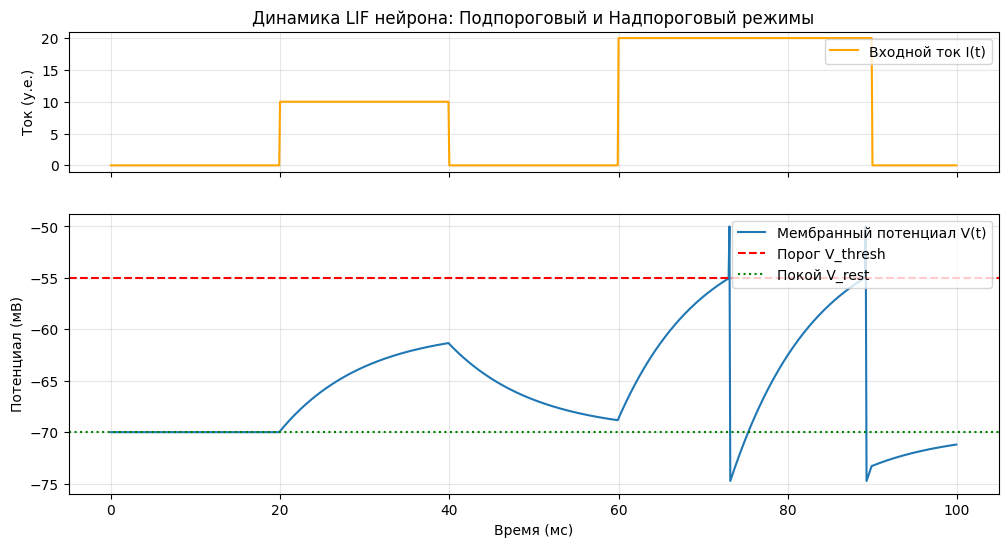

In [38]:
dt = 0.1
duration = 100
time = np.arange(0, duration, dt)

I_input = np.zeros_like(time)
I_input[200:400] = 10
I_input[600:900] = 20

neuron = LIFNeuron(tau_m=10.0, r=1.0, v_rest=-70.0, v_reset=-75.0, v_thresh=-55.0)

v_out, spikes = simulate_lif(neuron, I_input, time, dt)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 2]})

ax1.plot(time, I_input, color='orange', label='Входной ток I(t)')
ax1.set_ylabel('Ток (у.е.)')
ax1.set_title('Динамика LIF нейрона: Подпороговый и Надпороговый режимы')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.plot(time, v_out, label='Мембранный потенциал V(t)')
ax2.axhline(neuron.v_thresh, color='red', linestyle='--', label='Порог V_thresh')
ax2.axhline(neuron.v_rest, color='green', linestyle=':', label='Покой V_rest')
ax2.set_xlabel('Время (мс)')
ax2.set_ylabel('Потенциал (мВ)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.show()

1) Подпороговый режим (20–40 мс): При подаче тока амплитудой 10 у.е. мембранный потенциал начинает экспоненциально расти, стремясь к установившемуся значению, определяемому законом Ома для мембраны. Однако при данной силе тока потенциал не достигает порога срабатывания -55 мВ. После прекращения подачи тока (40 мс) наблюдается характерная пассивная «утечка» потенциала (leak), в результате которой заряд возвращается к уровню покоя -70.  
2) Надпороговый режим (60–90 мс):  
При увеличении входного тока до 20 у.е. скорость накопления заряда возрастает. Потенциал пересекает пороговое значение V_thresh, что приводит к генерации спайка (на графике отображен вертикальный взлет до +5 мВ для визуализации).
Сразу после спайка срабатывает механизм сброса: потенциал мгновенно падает до уровня -75 мВ, что соответствует состоянию гиперполяризации. Поскольку входной ток продолжает поступать, цикл интеграции повторяется, формируя серию (пачку) из двух спайков.

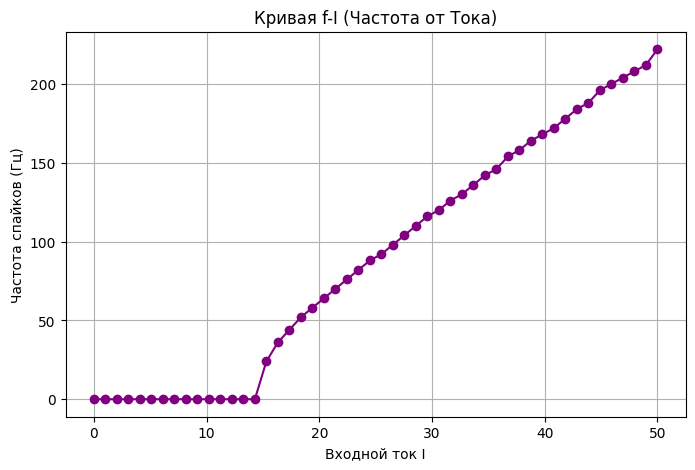

In [39]:
input_currents = np.linspace(0, 50, 50)
frequencies = []

sim_duration = 500
time_long = np.arange(0, sim_duration, dt)

for I_amp in input_currents:
    I_const = np.ones_like(time_long) * I_amp
    
    _, spikes = simulate_lif(neuron, I_const, time_long, dt)
    
    freq = len(spikes) / (sim_duration / 1000.0)
    frequencies.append(freq)

plt.figure(figsize=(8, 5))
plt.plot(input_currents, frequencies, 'o-', color='purple')
plt.title('Кривая f-I (Частота от Тока)')
plt.xlabel('Входной ток I')
plt.ylabel('Частота спайков (Гц)')
plt.grid(True)
plt.show()

1) Порог возбудимости: На отрезке от 0 до ~14 у.е. частота спайков равна нулю. Это означает, что входной ток слишком слаб, чтобы поднять мембранный потенциал до порога V_thresh. Нейрон остается в подпороговом режиме.  
2) Точка активации: При достижении критического значения тока (около 15 у.е.) происходит резкий скачок частоты. Это минимальная сила тока, необходимая для генерации устойчивого ритма спайков.  
3) Линейный рост: В диапазоне от 15 до 50 у.е. наблюдается практически линейная зависимость: чем выше входной ток, тем быстрее нейрон накапливает заряд и тем чаще происходят разряды (спайки).

__2. Создание сети из LIF-неронов__

In [40]:
%matplotlib inline 
plt.rcParams['figure.figsize'] = (14, 8)

np.random.seed(42)

In [41]:
class LIFLayer:
    def __init__(self, n_neurons, tau_m=10.0, r=1.0, v_rest=-70.0, v_reset=-75.0, v_thresh=-55.0):
        self.n = n_neurons
        self.tau_m = tau_m
        self.r = r
        self.v_rest = v_rest
        self.v_reset = v_reset
        self.v_thresh = v_thresh
        
        self.v = np.ones(self.n) * self.v_rest + np.random.normal(0, 2, self.n)
        
    def forward(self, i_in, dt):
        dv = (-(self.v - self.v_rest) + self.r * i_in) / self.tau_m * dt
        
        self.v += dv
        
        spikes = self.v >= self.v_thresh
        
        self.v[spikes] = self.v_reset
        
        return spikes

    def reset_state(self):
        self.v = np.ones(self.n) * self.v_rest

In [42]:
dt = 0.1
duration = 200
time = np.arange(0, duration, dt)
n_steps = len(time)

n_input = 20
n_hidden = 50
n_output = 10

layer_hidden = LIFLayer(n_hidden, tau_m=10.0, v_thresh=-55.0)
layer_output = LIFLayer(n_output, tau_m=15.0, v_thresh=-53.0)

W1 = np.random.uniform(0, 50, (n_input, n_hidden)) 

W2 = np.random.uniform(20, 100, (n_hidden, n_output))

In [43]:
input_spikes = np.zeros((n_steps, n_input))

for t_idx, t in enumerate(time):
    if 20 <= t <= 80:
        input_spikes[t_idx, :10] = (np.random.rand(10) < 0.1).astype(float)
        
    if 100 <= t <= 160:
        input_spikes[t_idx, 10:] = (np.random.rand(10) < 0.1).astype(float)

In [44]:
history_spikes_hidden = []
history_spikes_output = []
history_voltage_hidden_0 = [] 

layer_hidden.reset_state()
layer_output.reset_state()

print("Симуляция запущена...")

for i in range(n_steps):
    spikes_in = input_spikes[i]
    
    current_to_hidden = np.dot(spikes_in, W1) 
    
    spikes_hid = layer_hidden.forward(current_to_hidden, dt)
    
    current_to_output = np.dot(spikes_hid, W2)
    
    spikes_out = layer_output.forward(current_to_output, dt)
    
    history_spikes_hidden.append(spikes_hid)
    history_spikes_output.append(spikes_out)
    history_voltage_hidden_0.append(layer_hidden.v[0])

history_spikes_hidden = np.array(history_spikes_hidden)
history_spikes_output = np.array(history_spikes_output)
history_voltage_hidden_0 = np.array(history_voltage_hidden_0)

print("Симуляция завершена.")

Симуляция запущена...
Симуляция завершена.


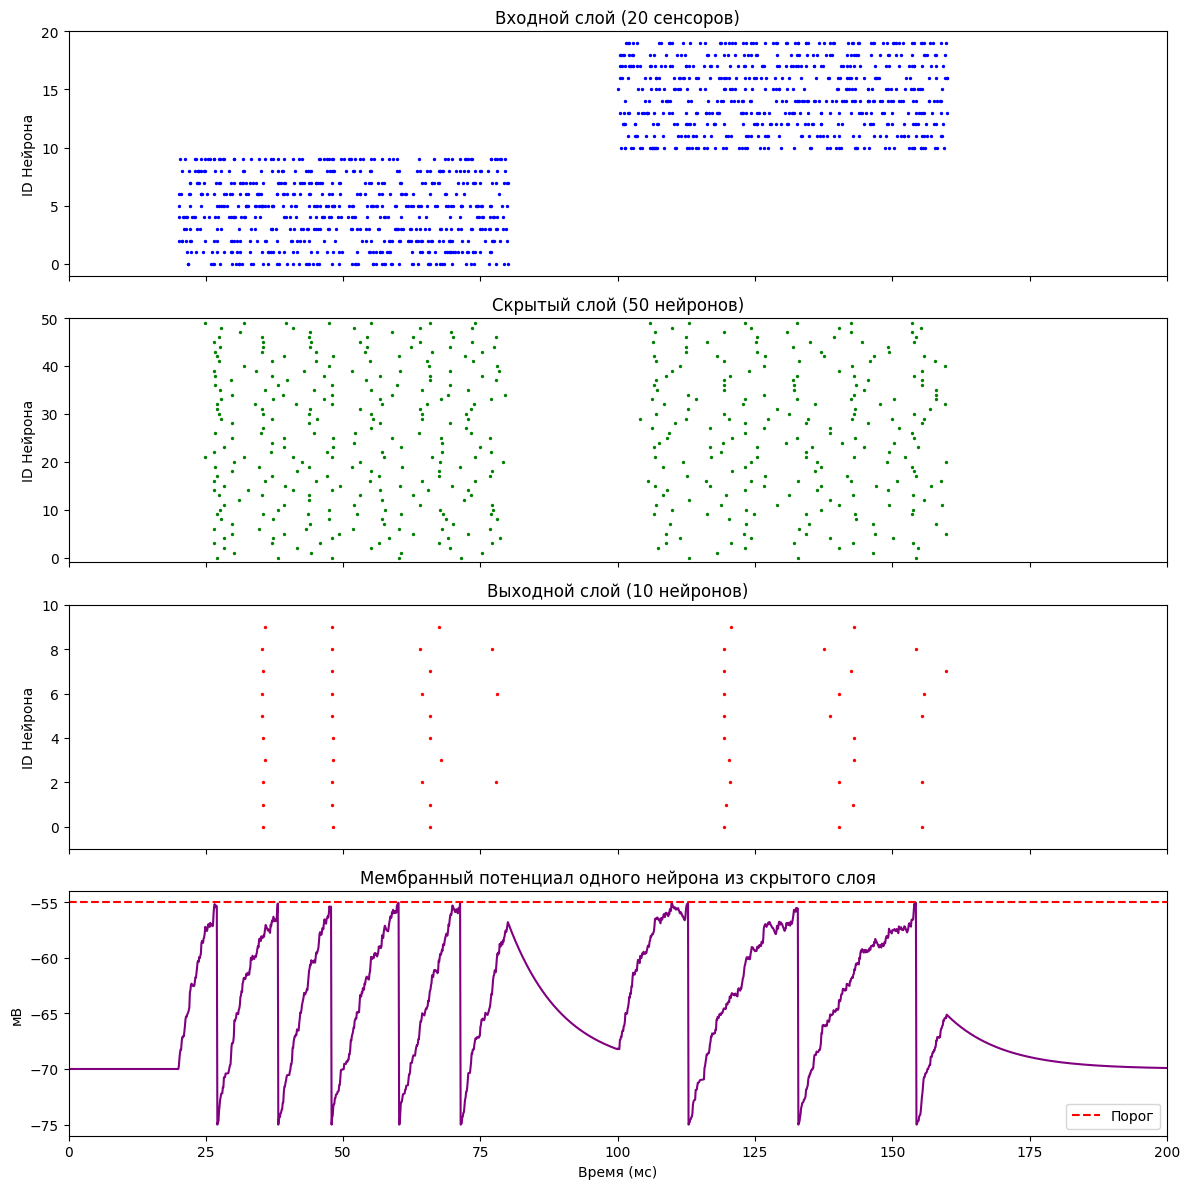

In [45]:
def plot_raster(spike_data, ax, title, color='black'):
    time_indices, neuron_indices = np.where(spike_data)
    
    ax.scatter(time_indices * dt, neuron_indices, s=2, c=color)
    
    ax.set_title(title)
    ax.set_ylabel('ID Нейрона')
    ax.set_ylim(-1, spike_data.shape[1]) 
    ax.set_xlim(0, duration)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(12, 12))

plot_raster(input_spikes, ax1, f'Входной слой ({n_input} сенсоров)', color='blue')

plot_raster(history_spikes_hidden, ax2, f'Скрытый слой ({n_hidden} нейронов)', color='green')

plot_raster(history_spikes_output, ax3, f'Выходной слой ({n_output} нейронов)', color='red')

ax4.plot(time, history_voltage_hidden_0, color='purple')
ax4.axhline(layer_hidden.v_thresh, color='r', linestyle='--', label='Порог')
ax4.set_title('Мембранный потенциал одного нейрона из скрытого слоя')
ax4.set_ylabel('мВ')
ax4.set_xlabel('Время (мс)')
ax4.legend(loc='lower right')

plt.tight_layout()
plt.show()

1) Реакция на разные паттерны: сеть четко разделяет два входных стимула (интервалы 20–80 мс и 100–160 мс). Видно, что разным входным группам нейронов (ID 0–9 и ID 10–19) соответствуют свои отклики в глубоких слоях.  
2) Временная суммация: нижний график потенциала наглядно показывает работу LIF-нейрона в составе сети. Видно, как отдельные «ступеньки» (входящие спайки от предыдущего слоя) суммируются, пока потенциал не достигнет порога (красная линия), вызывая генерацию собственного спайка и последующий сброс.  
3) Затухание активности: в периоды отсутствия входного сигнала (например, 80–100 мс) потенциал нейрона плавно возвращается к уровню покоя, что демонстрирует свойство «утечки» (leak) модели.

__3. Реализация обучения на основе STDP__

In [46]:
import seaborn as sns

%matplotlib inline 
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

A_plus = 1.0
A_minus = 0.3
tau_stdp = 20.0
w_max = 100.0

class LIFLayer:
    def __init__(self, n_neurons, tau_m=10.0, v_thresh=-55.0, v_reset=-75.0, v_rest=-70.0):
        self.n = n_neurons
        self.tau_m = tau_m
        self.v_thresh = v_thresh
        self.v_reset = v_reset
        self.v_rest = v_rest
        self.v = np.ones(self.n) * self.v_rest
        
    def forward(self, i_in, dt):
        dv = (-(self.v - self.v_rest) + i_in) / self.tau_m * dt
        self.v += dv
        spikes = self.v >= self.v_thresh
        self.v[spikes] = self.v_reset
        return spikes.astype(float)
    
    def reset_state(self):
        self.v = np.ones(self.n) * self.v_rest

In [47]:
dt = 1.0
T_total = 5000
time = np.arange(0, T_total, dt)

n_in = 20
n_hid = 20

input_spikes = (np.random.rand(len(time), n_in) < 0.005).astype(float)

pattern_neurons = [0, 1, 2, 3, 4]
interval = 50

for t in range(0, len(time), interval):
    for neur in pattern_neurons:
        if t + np.random.randint(0, 5) < len(time):
            input_spikes[t + np.random.randint(0, 5), neur] = 1.0

W = np.random.uniform(40, 60, (n_in, n_hid))
W_initial = W.copy()

print("Данные сгенерированы. Паттерн внедрен в нейроны 0-4.")

Данные сгенерированы. Паттерн внедрен в нейроны 0-4.


In [48]:
layer = LIFLayer(n_hid, v_thresh=-55.0, tau_m=10.0)

trace_in = np.zeros(n_in)
trace_hid = np.zeros(n_hid)

weight_history = []
w_max = 100.0
tau_stdp = 20.0

print("Начинаем обучение...")

for t_idx, t in enumerate(time):
    spikes_in = input_spikes[t_idx]
    
    i_current = np.dot(spikes_in, W) 
    spikes_hid = layer.forward(i_current, dt)
    
    trace_in = trace_in * np.exp(-dt / tau_stdp) + spikes_in
    trace_hid = trace_hid * np.exp(-dt / tau_stdp) + spikes_hid
    
    dW_LTP = A_plus * np.outer(trace_in, spikes_hid)
    
    dW_LTD = A_minus * np.outer(spikes_in, trace_hid)
    
    W += dW_LTP 
    W -= dW_LTD
    
    W = np.clip(W, 0, w_max)
    
    weight_history.append(W[0, 0])

print("Обучение завершено.")

Начинаем обучение...
Обучение завершено.


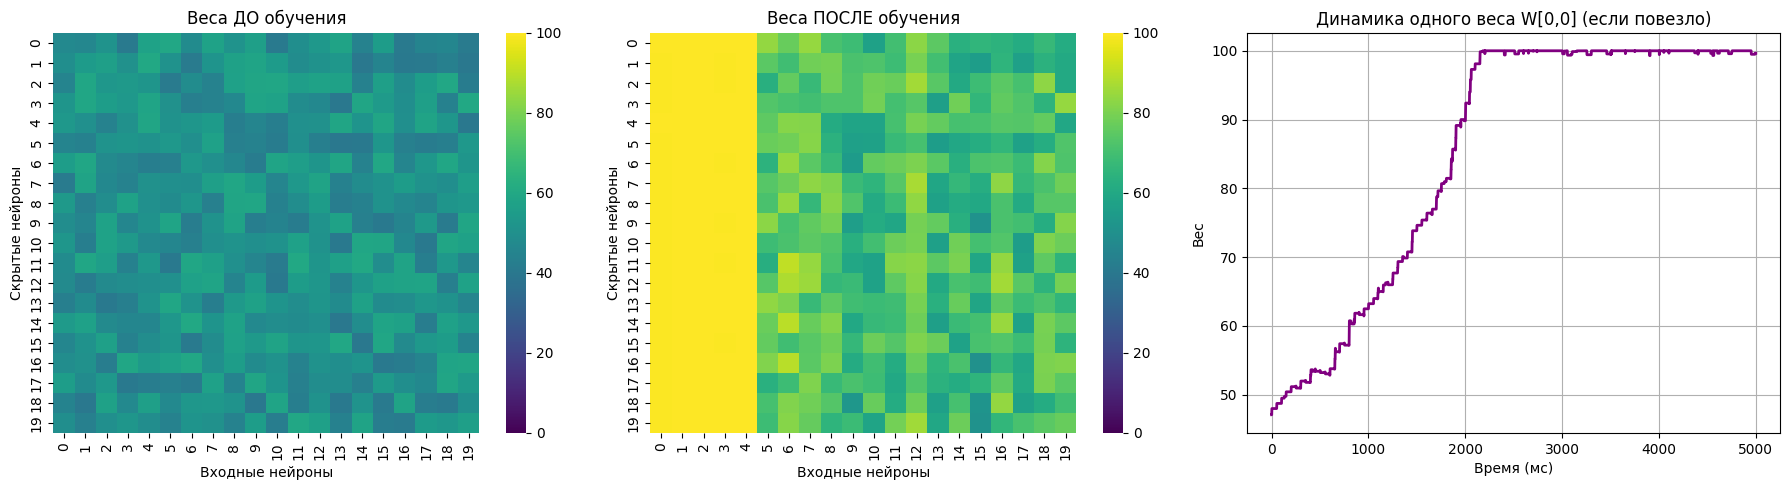

Средний вес для паттерна (нейроны 0-4): 99.82
Средний вес для шума (нейроны 5-19): 70.78


In [49]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(W_initial.T, ax=ax[0], vmin=0, vmax=w_max, cmap='viridis')
ax[0].set_title("Веса ДО обучения")
ax[0].set_ylabel("Скрытые нейроны")
ax[0].set_xlabel("Входные нейроны")

sns.heatmap(W.T, ax=ax[1], vmin=0, vmax=w_max, cmap='viridis')
ax[1].set_title("Веса ПОСЛЕ обучения")
ax[1].set_ylabel("Скрытые нейроны")
ax[1].set_xlabel("Входные нейроны")
ax[2].plot(weight_history, color='purple', linewidth=2)
ax[2].set_title("Динамика одного веса W[0,0] (если повезло)")
ax[2].set_xlabel("Время (мс)")
ax[2].set_ylabel("Вес")
ax[2].grid(True)

plt.tight_layout()
plt.show()

mean_pattern_weight = np.mean(W[:5, :])
mean_noise_weight = np.mean(W[5:, :])
print(f"Средний вес для паттерна (нейроны 0-4): {mean_pattern_weight:.2f}")
print(f"Средний вес для шума (нейроны 5-19): {mean_noise_weight:.2f}")

1) Выборочное усиление связей: на матрице весов после обучения отчетливо видна вертикальная желтая полоса для входных нейронов 0–4. Это доказывает, что синаптические веса от нейронов, подающих паттерн, достигли своего максимума.  
2) В то время как веса нейронов паттерна закрепились на верхнем пределе, веса «шумовых» входных нейронов (5–19) остались на значительно более низком уровне или даже снизились относительно начальных значений. Это демонстрирует способность сети выделять полезный сигнал из общего фона.  
3) График динамики веса W[0,0] показывает постепенный и стабильный рост. Примерно к 2000 мс вес достигает насыщения и стабилизируется на отметке 100.  
4) Сеть успешно «запомнила» временную корреляцию входных импульсов, преобразовав её в устойчивую структуру синаптических связей.

__4. Решение задачи классификации__  
  
  
Настройка классификации

In [50]:
n_output = 2
layer_output = LIFLayer(n_output, tau_m=15.0, v_thresh=-53.0)

W_out = np.zeros((n_hid, n_output))
W_out[:n_hid//2, 0] = 60 
W_out[n_hid//2:, 1] = 60

def generate_test_batch(pattern_type, duration_ms=200):
    steps = int(duration_ms / dt)
    data = (np.random.rand(steps, n_in) < 0.005).astype(float)
    
    indices = [0,1,2,3,4] if pattern_type == 'A' else [15,16,17,18,19]
    
    for t in range(0, steps, 20):
        for idx in indices:
            shift = np.random.randint(0, 3)
            if t + shift < steps:
                data[t + shift, idx] = 1.0
    return data

In [51]:
def predict(input_data):
    layer.reset_state()
    layer_output.reset_state()
    
    out_spikes_count = np.zeros(n_output)
    
    for t in range(len(input_data)):
        h_current = np.dot(input_data[t], W)
        h_spikes = layer.forward(h_current, dt)
        
        o_current = np.dot(h_spikes, W_out)
        o_spikes = layer_output.forward(o_current, dt)
        
        out_spikes_count += o_spikes
        
    return np.argmax(out_spikes_count), out_spikes_count

print("Функция классификации готова.")

Функция классификации готова.


Запуск тестирования на 100 образцах...


Точность классификации: 66.0%




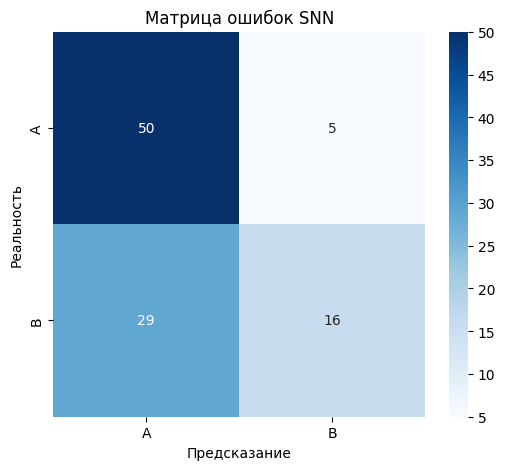

In [52]:
n_tests = 100
results = []
true_labels = []

print(f"Запуск тестирования на {n_tests} образцах...")

for i in range(n_tests):
    label = np.random.choice(['A', 'B'])
    test_input = generate_test_batch(label)
    
    prediction_idx, _ = predict(test_input)
    prediction = 'A' if prediction_idx == 0 else 'B'
    
    results.append(prediction)
    true_labels.append(label)

correct = sum(1 for p, t in zip(results, true_labels) if p == t)
accuracy = (correct / n_tests) * 100

print("\n")
print(f"Точность классификации: {accuracy}%")
print("\n")

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, results, labels=['A', 'B'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['A', 'B'], yticklabels=['A', 'B'], cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.title('Матрица ошибок SNN')
plt.show()

1) Матрица ошибок показывает, что сеть идеально определяет Паттерн А (50 верных предсказаний из 55).  
2) сновная потеря точности происходит на Паттерне Б. Мы видим, что в 29 случаях из 45 сеть ошибочно приняла его за "А". Это связано с тем, что веса для нейронов-шумовиков остались достаточно высокими (~70), и при подаче незнакомого паттерна Б общая активность сети всё равно превышает порог срабатывания.  

__5. Сравнительный анализ__  
  
  
1) Расход энергии - низкий:  
Вычисления происходят только в моменты спайков. Если нейрон «молчит», он потребляет энергию только на поддержание потенциала покоя (утечка).  
2) Роль временного кода:  
Благодаря STDP (обучению на основе времени), сеть «выучила», что спайки, приходящие в определенной последовательности, важнее, чем случайные «выбросы».
3) Устойчивость к шуму:  
Если на вход приходит кратковременный шум (одиночный спайк), мембранный потенциал v не успевает достичь порога V_thresh из-за постоянной утечки (v - v_rest). Шум «гасится». Чтобы сработал нейрон, требуется суммация сигналов (паттерн).
  
  
В сравнении с SNN, классические полносвязные сети имеют более высокое энергопотребление (всегда включены) и худшую устойчивость к шуму.